# Turtle Accelerometer Data — Statistics Analysis

**Dataset**: Sea turtle behavior classification using tri-axial accelerometer, gyroscope, and pressure  
**Data source**: `data/turtle/raw/doi_10_5061/` (HDF5 sensor files + Behavior CSV annotations)  
**Windowed cache**: `data/turtle/data.npy` / `data/turtle/label.npy`

**H5 columns**: [acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z, pressure] — 7 channels @ 200 Hz  
**Behavior annotations**: semicolon-separated CSV per individual session

**Label names** (canonical grouping):
| ID | Behavior |
|----|----------|
| 0  | Resting |
| 1  | Swimming |
| 2  | Stay_in_surface |
| 3  | Gliding |
| 4  | Feeding |
| 5  | Scratching |
| 6  | Breathing |

## 0. Imports & Configuration

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from collections import Counter
import h5py
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.labelsize': 11})
sns.set_palette('tab10')

NOTEBOOK_DIR = os.path.abspath('')
DATA_DIR     = os.path.join(NOTEBOOK_DIR, '..', '..', 'data', 'turtle')
RAW_DIR      = os.path.join(DATA_DIR, 'raw', 'doi_10_5061')
NPY_DATA     = os.path.join(DATA_DIR, 'data.npy')
NPY_LABEL    = os.path.join(DATA_DIR, 'label.npy')
FIG_DIR      = os.path.join(NOTEBOOK_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

# Map raw behavior strings to canonical label IDs
BEHAVIOR_TO_LABEL = {
    # Resting
    'Resting': 0, 'Resting in flow': 0, 'Resting active': 0, 'Resting watching': 0,
    # Swimming
    'Swimming horizontally': 1, 'Swimming ascent': 1, 'Swimming descent': 1,
    'Swimming on the bottom': 1, 'Swimming 1 horizontally': 1, 'Swimming 1 ascent': 1,
    'Swimming 1 descent': 1, 'Swimming fast horizontally': 1, 'Swimming fast ascent': 1,
    'Swimming fast descent': 1, 'Swimming in place': 1, 'Flipper beat': 1, 'Escape': 1,
    # Stay in surface
    'Stay in surface': 2,
    # Gliding
    'Gliding ascent': 3, 'Gliding descent': 3,
    # Feeding
    'Catching': 4, 'Catching jellyfish': 4, 'Chewing jellyfish': 4,
    'Chewing on movement': 4, 'Chewing stationary': 4, 'Foraging': 4,
    'Grabbing on movement': 4, 'Grabbing stationary': 4, 'Hunting jellyfish': 4,
    'Regurgitating': 4, 'Prospection': 4, 'Pursuit': 4, 'Sand': 4,
    # Scratching
    'Scratching': 5, 'Scratching camera': 5, 'Scratching head': 5,
    # Breathing
    'Breathing': 6,
}

LABEL_NAMES = {
    0: 'Resting', 1: 'Swimming', 2: 'Stay_in_surface',
    3: 'Gliding', 4: 'Feeding', 5: 'Scratching', 6: 'Breathing',
}

AXES        = ['acc_x', 'acc_y', 'acc_z']
ALL_AXES    = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'pressure']
COLORS      = plt.cm.tab10(np.linspace(0, 1, 10))
SAMPLE_RATE = 20  # Hz
WINDOW_SIZE = 200  # timesteps = 1 sec

print('raw dir :', RAW_DIR)
print('npy     :', NPY_DATA)
print('figs    :', FIG_DIR)

raw dir : /Users/cassie/Documents/code/DeepView/analysis/turtle/../../data/turtle/raw/doi_10_5061
npy     : /Users/cassie/Documents/code/DeepView/analysis/turtle/../../data/turtle/data.npy
figs    : /Users/cassie/Documents/code/DeepView/analysis/turtle/figures


## 1. Preprocessing: H5 + Behavior CSV → Windowed npy

Pipeline:
1. For each session: load H5 sensor data (N, 7) and behavior CSV
2. Assign label to each sample using `Start (s)` / `Stop (s)` offsets; unlabeled → -1
3. Concatenate all sessions
4. Z-score normalize acc_x/y/z globally (same as `gaussian_std`)
5. Sliding window (size=200, step=200, non-overlapping), keeping windows with ≥80% same label
6. Save `data.npy` shape `(N, 3, 200)` and `label.npy` shape `(N, 200)`

In [2]:
def sliding_window(data_np, len_sw, step):
    windows = []
    for idx in range(0, data_np.shape[0] - len_sw - step, step):
        windows.append(data_np[idx: idx + len_sw, :])
    if len(data_np) >= len_sw:
        windows.append(data_np[-len_sw:, :])
    return np.stack(windows, axis=0) if windows else np.empty((0, len_sw, data_np.shape[1]))


def load_session(h5_path, csv_path):
    """Load one session and return (sensor_array, label_array, individual_id)."""
    with h5py.File(h5_path, 'r') as f:
        sensor = f['data'][:]          # (N, 7)

    n_samples = sensor.shape[0]
    labels    = np.full(n_samples, -1, dtype=int)

    try:
        beh = pd.read_csv(csv_path, sep=';')
        for _, row in beh.iterrows():
            beh_str = str(row.get('Behavior', '')).strip()
            label_id = BEHAVIOR_TO_LABEL.get(beh_str, -1)
            if label_id < 0:
                continue
            start_s = float(row.get('Start (s)', -1))
            stop_s  = float(row.get('Stop (s)',  -1))
            if start_s < 0 or stop_s < 0:
                continue
            i_start = max(0, int(start_s * SAMPLE_RATE))
            i_stop  = min(n_samples, int(stop_s * SAMPLE_RATE))
            if i_start < i_stop:
                labels[i_start:i_stop] = label_id
    except Exception as e:
        print(f'  Warning loading {csv_path}: {e}')

    basename = os.path.basename(h5_path).replace('.h5', '')
    # individual = CC-07-XX portion
    individual = '-'.join(basename.split('-')[:3])
    return sensor, labels, individual


def build_windowed_npy(raw_dir, npy_data_path, npy_label_path,
                       len_sw=200, step=200):
    h5_files  = sorted(glob.glob(os.path.join(raw_dir, '*.h5')))
    all_sensor, all_labels, all_ids = [], [], []

    for h5_path in h5_files:
        basename = os.path.basename(h5_path).replace('.h5', '')
        csv_path = os.path.join(raw_dir, f'Behaviors_{basename}.csv')
        if not os.path.exists(csv_path):
            print(f'  No CSV for {basename}, skipping')
            continue
        sensor, labels, individual = load_session(h5_path, csv_path)
        print(f'  {basename}: {sensor.shape[0]} samples, '
              f'labeled={int((labels >= 0).sum())}  '
              f'({int((labels >= 0).mean()*100)}%)')
        all_sensor.append(sensor)
        all_labels.append(labels)
        all_ids.extend([individual] * len(labels))

    sensor_all = np.concatenate(all_sensor, axis=0)
    labels_all = np.concatenate(all_labels, axis=0)
    ids_all    = np.array(all_ids)
    print(f'\nTotal samples: {len(sensor_all):,}')
    print(f'Labeled samples: {int((labels_all >= 0).sum()):,}')

    # Normalize acc channels globally (only over labeled samples for robustness)
    labeled_mask = labels_all >= 0
    acc = sensor_all[:, :3].astype(float)
    mean_v = acc[labeled_mask].mean(axis=0)
    std_v  = np.maximum(acc[labeled_mask].std(axis=0), 1e-5)
    sensor_all[:, :3] = (acc - mean_v) / std_v

    # Sliding window
    combined = np.concatenate([sensor_all, labels_all[:, None], 
                               np.arange(len(labels_all))[:, None]], axis=1)
    print('Applying sliding window ...')
    windows = sliding_window(combined, len_sw, step)

    # Keep only windows where a majority (>=50%) of samples have a label
    win_labels = windows[:, :, 7].astype(int)   # shape (W, len_sw)
    majority_label = np.array([Counter(w[w >= 0]).most_common(1)[0][0]
                                if (w >= 0).sum() > 0 else -1
                                for w in win_labels])
    labeled_frac = (win_labels >= 0).mean(axis=1)
    keep = (majority_label >= 0) & (labeled_frac >= 0.5)

    windows = windows[keep]
    majority_label = majority_label[keep]
    print(f'Windows (≥50% labeled): {keep.sum()} / {len(keep)}')

    data_b  = np.transpose(windows[:, :, :3], (0, 2, 1))  # (W, 3, 200)
    label_b = windows[:, :, 7].astype(int)                  # (W, 200)

    np.save(npy_data_path, data_b)
    np.save(npy_label_path, label_b)
    print(f'Saved data.npy  : {data_b.shape}')
    print(f'Saved label.npy : {label_b.shape}')
    return data_b, label_b


if os.path.exists(NPY_DATA) and os.path.exists(NPY_LABEL):
    print('Loading cached npy ...')
    X = np.load(NPY_DATA)
    Y = np.load(NPY_LABEL)
else:
    X, Y = build_windowed_npy(RAW_DIR, NPY_DATA, NPY_LABEL)

# Per-window majority label
from collections import Counter as _Counter
y = np.array([_Counter(row[row >= 0]).most_common(1)[0][0]
              if (row >= 0).sum() > 0 else -1
              for row in Y])
mask_valid = y >= 0
X, Y, y   = X[mask_valid], Y[mask_valid], y[mask_valid]

labels_to_analyze = sorted(np.unique(y))
class_names       = [LABEL_NAMES.get(l, str(l)) for l in labels_to_analyze]

print(f'X shape       : {X.shape}')
print(f'Unique labels : {labels_to_analyze}')
print(f'Label counts  : {dict(sorted(Counter(y).items()))}')

  CC-07-107_11-02-2019: 375100 samples, labeled=266501  (71%)
  CC-07-108_11-02-2019: 169560 samples, labeled=110099  (64%)
  CC-07-115_13-05-2019: 758480 samples, labeled=670299  (88%)
  CC-07-115_14-05-2019: 360001 samples, labeled=135301  (37%)
  CC-07-47_14-02-2018: 126000 samples, labeled=9581  (7%)
  CC-07-48_04-10-2018: 344160 samples, labeled=0  (0%)
  CC-07-48_06-10-2018: 550000 samples, labeled=483648  (87%)
  CC-07-48_08-04-2019_1: 171421 samples, labeled=82362  (48%)
  CC-07-48_08-04-2019_2: 186000 samples, labeled=0  (0%)
  CC-07-48_08-04-2019_3: 168001 samples, labeled=5601  (3%)
  CC-07-48_08-10-2018: 560000 samples, labeled=354461  (63%)
  CC-07-48_10-10-2018: 122040 samples, labeled=0  (0%)
  CC-07-48_18-02-2019: 590000 samples, labeled=313440  (53%)
  CC-07-48_22-05-2018: 304000 samples, labeled=273673  (90%)
  CC-07-48_26-05-2018: 296000 samples, labeled=181428  (61%)
  CC-07-59_20-05-2018: 471180 samples, labeled=237980  (50%)

Total samples: 5,551,943
Labeled sampl

## 2. Build raw-data DataFrame for global statistics

In [3]:
# Collect raw labeled samples for global stats (acc_x/y/z, individual)
h5_files = sorted(glob.glob(os.path.join(RAW_DIR, '*.h5')))
rows_list = []
for h5_path in h5_files:
    basename = os.path.basename(h5_path).replace('.h5', '')
    csv_path = os.path.join(RAW_DIR, f'Behaviors_{basename}.csv')
    if not os.path.exists(csv_path): continue
    with h5py.File(h5_path, 'r') as f:
        sensor = f['data'][:]
    n = sensor.shape[0]
    labels_s = np.full(n, -1, dtype=int)
    try:
        beh = pd.read_csv(csv_path, sep=';')
        for _, row in beh.iterrows():
            beh_str  = str(row.get('Behavior', '')).strip()
            label_id = BEHAVIOR_TO_LABEL.get(beh_str, -1)
            if label_id < 0: continue
            start_s, stop_s = float(row.get('Start (s)',-1)), float(row.get('Stop (s)',-1))
            if start_s < 0 or stop_s < 0: continue
            i0, i1 = max(0, int(start_s*SAMPLE_RATE)), min(n, int(stop_s*SAMPLE_RATE))
            if i0 < i1: labels_s[i0:i1] = label_id
    except: pass
    ind = '-'.join(basename.split('-')[:3])
    df_s = pd.DataFrame(sensor, columns=ALL_AXES)
    df_s['label_id']    = labels_s
    df_s['individual']  = ind
    rows_list.append(df_s)

df_all   = pd.concat(rows_list, ignore_index=True)
df_known = df_all[df_all['label_id'] >= 0].copy()
print(f'Total samples: {len(df_all):,}')
print(f'Labeled samples: {len(df_known):,}')
print(f'\nIndividuals: {sorted(df_known["individual"].unique())}')
print(f'\nLabel distribution (raw):')
print(df_known['label_id'].value_counts().sort_index()
      .rename(index={k: f"{k}: {LABEL_NAMES.get(k,'?')}" for k in LABEL_NAMES}))

Total samples: 5,551,943
Labeled samples: 3,124,374

Individuals: ['CC-07-107_11', 'CC-07-108_11', 'CC-07-115_13', 'CC-07-115_14', 'CC-07-47_14', 'CC-07-48_06', 'CC-07-48_08', 'CC-07-48_18', 'CC-07-48_22', 'CC-07-48_26', 'CC-07-59_20']

Label distribution (raw):
label_id
0: Resting             564076
1: Swimming           2043536
2: Stay_in_surface     279115
3: Gliding             100193
4: Feeding              42497
5: Scratching           12781
6: Breathing            82176
Name: count, dtype: int64


## 3. Class Distribution

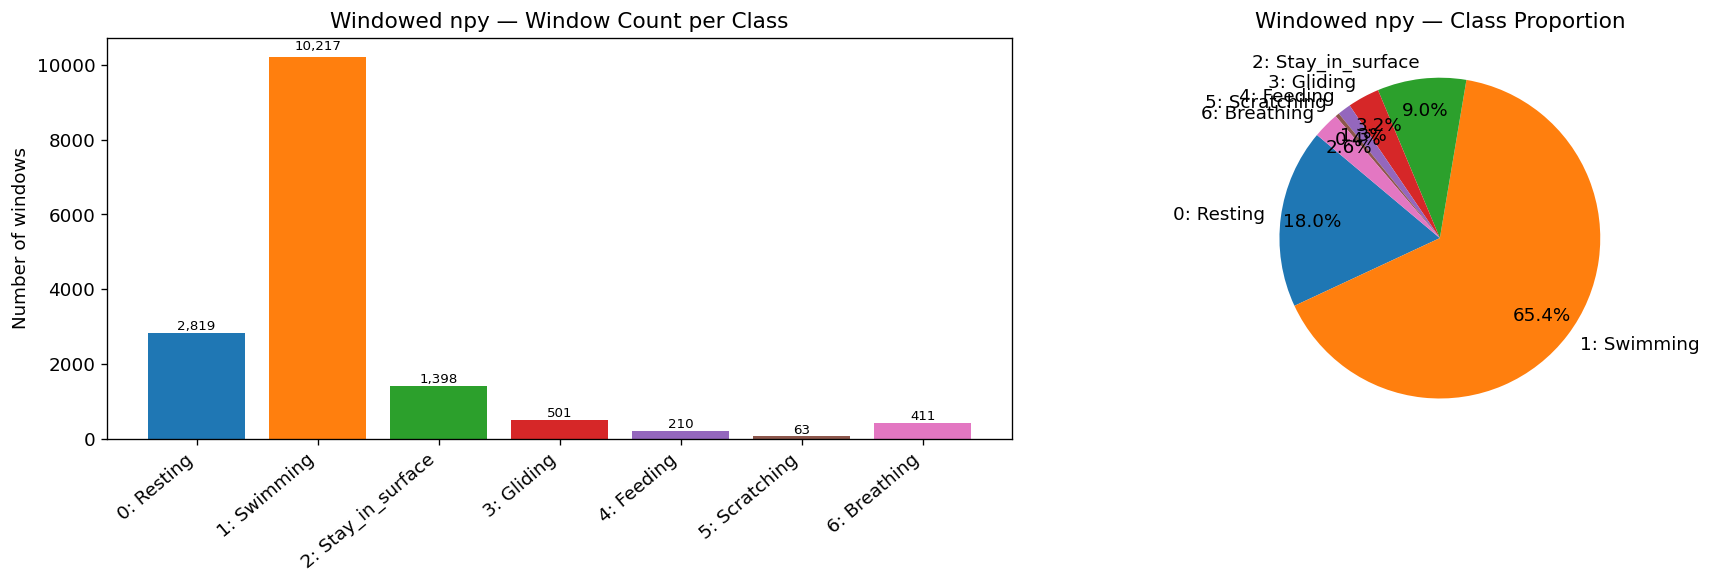

In [4]:
cnt    = Counter(y)
counts = [cnt.get(l, 0) for l in labels_to_analyze]
props  = np.array(counts) / sum(counts) * 100
names  = [f"{l}: {LABEL_NAMES.get(l,'?')}" for l in labels_to_analyze]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax = axes[0]
bars = ax.bar(range(len(labels_to_analyze)), counts, color=COLORS[:len(labels_to_analyze)])
ax.set_xticks(range(len(labels_to_analyze)))
ax.set_xticklabels(names, rotation=40, ha='right')
ax.set_title('Windowed npy — Window Count per Class')
ax.set_ylabel('Number of windows')
for bar, v in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
            f'{v:,}', ha='center', va='bottom', fontsize=8)

ax = axes[1]
ax.pie(props, labels=names, autopct='%1.1f%%', colors=COLORS[:len(labels_to_analyze)],
       startangle=140, pctdistance=0.8)
ax.set_title('Windowed npy — Class Proportion')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'class_dist_npy.png'), bbox_inches='tight')
plt.show()

In [5]:
p           = np.array(counts) / sum(counts)
entropy     = -np.sum(p * np.log2(p + 1e-12))
max_entropy = np.log2(len(p))
gini        = 1 - np.sum(p**2)
ir          = max(p) / (min(p) + 1e-12)

print('=== Class Imbalance Metrics ===')
print(f'  Classes          : {len(p)}')
print(f'  Shannon entropy  : {entropy:.4f}  (max = {max_entropy:.4f})')
print(f'  Normalized entropy: {entropy/max_entropy:.4f}')
print(f'  Gini impurity    : {gini:.4f}')
print(f'  Imbalance ratio  : {ir:.1f}x')
for label_id, pi in zip(labels_to_analyze, p):
    if pi > 0:
        w = (1/pi) / sum(1/q for q in p if q > 0)
    else:
        w = 0
    print(f'  {label_id} {LABEL_NAMES.get(label_id,"?"):<18} p={pi:.4f}  weight={w:.4f}')

=== Class Imbalance Metrics ===
  Classes          : 7
  Shannon entropy  : 1.5709  (max = 2.8074)
  Normalized entropy: 0.5596
  Gini impurity    : 0.5296
  Imbalance ratio  : 162.2x
  0 Resting            p=0.1805  weight=0.0135
  1 Swimming           p=0.6541  weight=0.0037
  2 Stay_in_surface    p=0.0895  weight=0.0273
  3 Gliding            p=0.0321  weight=0.0761
  4 Feeding            p=0.0134  weight=0.1815
  5 Scratching         p=0.0040  weight=0.6051
  6 Breathing          p=0.0263  weight=0.0928


In [6]:
# 计算每个 class 的总样本数/时长，以及连续段长度 >= 50 的统计
labels_arr = df_all['label_id'].values  # includes -1 for unlabeled
# detect run boundaries
changes = np.flatnonzero(np.r_[True, labels_arr[1:] != labels_arr[:-1], True])
starts, ends = changes[:-1], changes[1:]
run_vals = labels_arr[starts]
run_lens = ends - starts  # in samples

rows = []
for label in labels_to_analyze:
    mask_runs = run_vals == label
    total_samples = run_lens[mask_runs].sum()
    n_runs = mask_runs.sum()
    # runs >= 50 samples
    long_mask = mask_runs & (run_lens >= 50)
    n_long_runs = long_mask.sum()
    long_lens = run_lens[long_mask]
    rows.append({
        'label': label,
        'behavior': LABEL_NAMES.get(label, str(label)),
        'total_samples': int(total_samples),
        'total_minutes': total_samples / SAMPLE_RATE / 60,
        'n_runs': int(n_runs),
        'n_runs_>=50': int(n_long_runs),
        'mean_len_>=50_s': float(long_lens.mean()/SAMPLE_RATE) if len(long_lens)>0 else 0.0,
        'median_len_>=50_s': float(np.median(long_lens)/SAMPLE_RATE) if len(long_lens)>0 else 0.0,
        'max_len_>=50_s': float(long_lens.max()/SAMPLE_RATE) if len(long_lens)>0 else 0.0,
    })

runs_df = pd.DataFrame(rows).set_index('label')
pd.set_option('display.width', 200)
print('=== Per-class total length & long-run (>=50 samples) stats ===')
print(runs_df.to_string())

=== Per-class total length & long-run (>=50 samples) stats ===
              behavior  total_samples  total_minutes  n_runs  n_runs_>=50  mean_len_>=50_s  median_len_>=50_s  max_len_>=50_s
label                                                                                                                        
0              Resting         564076      47.006333      29           29        97.254483             43.630          518.00
1             Swimming        2043536     170.294667     297          297        34.402963             23.675          266.07
2      Stay_in_surface         279115      23.259583      42           42        33.227976             21.025          161.35
3              Gliding         100193       8.349417      77           77         6.506039              4.820           29.10
4              Feeding          42497       3.541417      15           15        14.165667             10.795           51.80
5           Scratching          12781       1.065083   

## 4. Per-Individual Analysis

Individuals: ['CC-07-107_11', 'CC-07-108_11', 'CC-07-115_13', 'CC-07-115_14', 'CC-07-47_14', 'CC-07-48_06', 'CC-07-48_08', 'CC-07-48_18', 'CC-07-48_22', 'CC-07-48_26', 'CC-07-59_20']


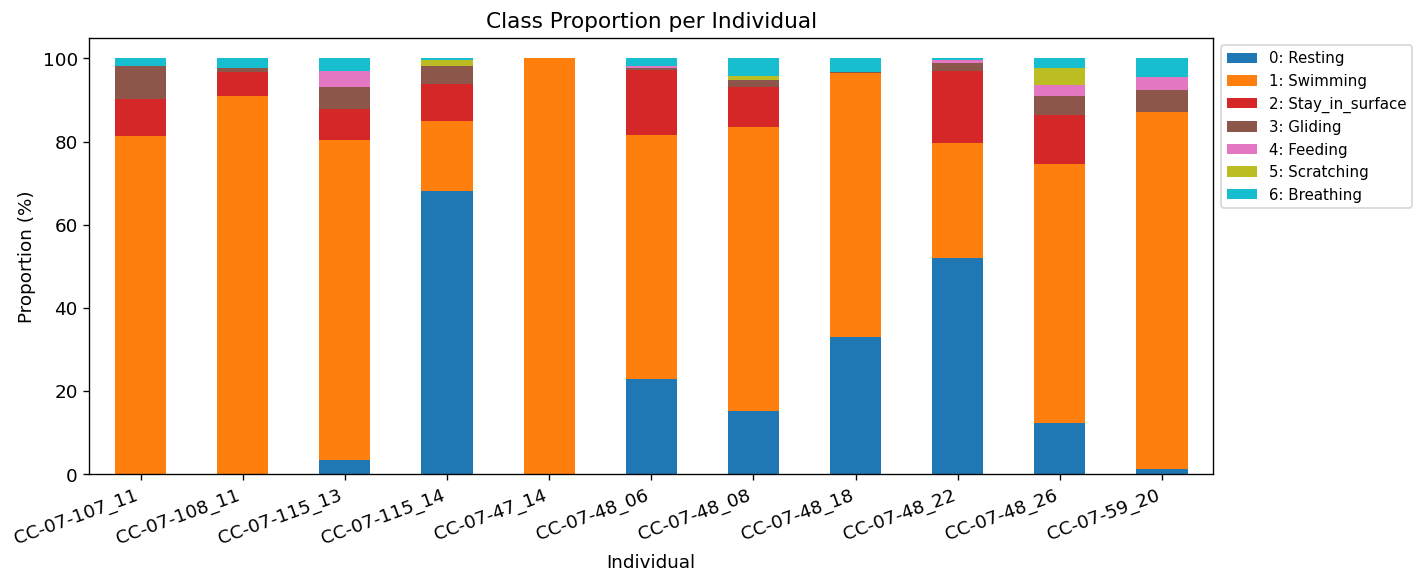

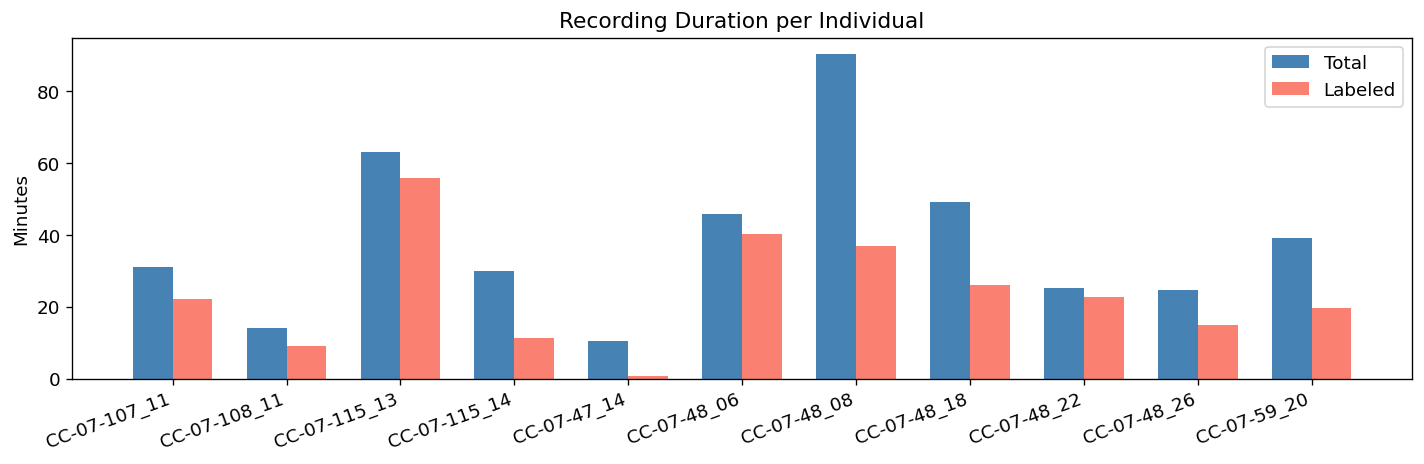

In [7]:
individuals = sorted(df_known['individual'].unique())
print(f'Individuals: {individuals}')

pivot_ind = df_known.groupby(['individual', 'label_id']).size().unstack(fill_value=0)
pivot_ind.columns = [f"{int(c)}: {LABEL_NAMES.get(int(c),'?')}" for c in pivot_ind.columns]

fig, ax = plt.subplots(figsize=(12, 5))
pivot_norm = pivot_ind.div(pivot_ind.sum(axis=1), axis=0) * 100
pivot_norm.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_title('Class Proportion per Individual')
ax.set_xlabel('Individual')
ax.set_ylabel('Proportion (%)')
ax.set_xticklabels(pivot_ind.index, rotation=20, ha='right')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'class_dist_per_individual.png'), bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ind_total   = df_all.groupby('individual').size() / SAMPLE_RATE / 60
ind_labeled = df_known.groupby('individual').size() / SAMPLE_RATE / 60
x = np.arange(len(individuals))
w = 0.35
ax.bar(x - w/2, ind_total.reindex(individuals, fill_value=0).values, w, label='Total', color='steelblue')
ax.bar(x + w/2, ind_labeled.reindex(individuals, fill_value=0).values, w, label='Labeled', color='salmon')
ax.set_xticks(x)
ax.set_xticklabels(individuals, rotation=20, ha='right')
ax.set_ylabel('Minutes')
ax.set_title('Recording Duration per Individual')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'recording_duration.png'), bbox_inches='tight')
plt.show()

## 5. Global Accelerometer Statistics

In [8]:
print('=== Raw accelerometer statistics (labeled samples, before normalization) ===')
print(df_known[AXES].describe().round(4).to_string())
print()
print('Skewness:', df_known[AXES].skew().round(4).to_dict())
print('Kurtosis:', df_known[AXES].kurtosis().round(4).to_dict())

=== Raw accelerometer statistics (labeled samples, before normalization) ===
              acc_x         acc_y         acc_z
count  3.124374e+06  3.124374e+06  3.124374e+06
mean  -1.682000e-01  1.000000e-04 -8.594000e-01
std    2.785000e-01  1.218000e-01  1.733000e-01
min   -1.644300e+00 -1.167300e+00 -2.146000e+00
25%   -3.388000e-01 -8.010000e-02 -1.026700e+00
50%   -1.857000e-01 -2.000000e-03 -8.303000e-01
75%    9.000000e-03  7.910000e-02 -7.661000e-01
max    1.077300e+00  1.728400e+00  6.843000e-01

Skewness: {'acc_x': 0.2888, 'acc_y': 0.0949, 'acc_z': 1.4212}
Kurtosis: {'acc_x': 1.0585, 'acc_y': 1.1467, 'acc_z': 4.6681}


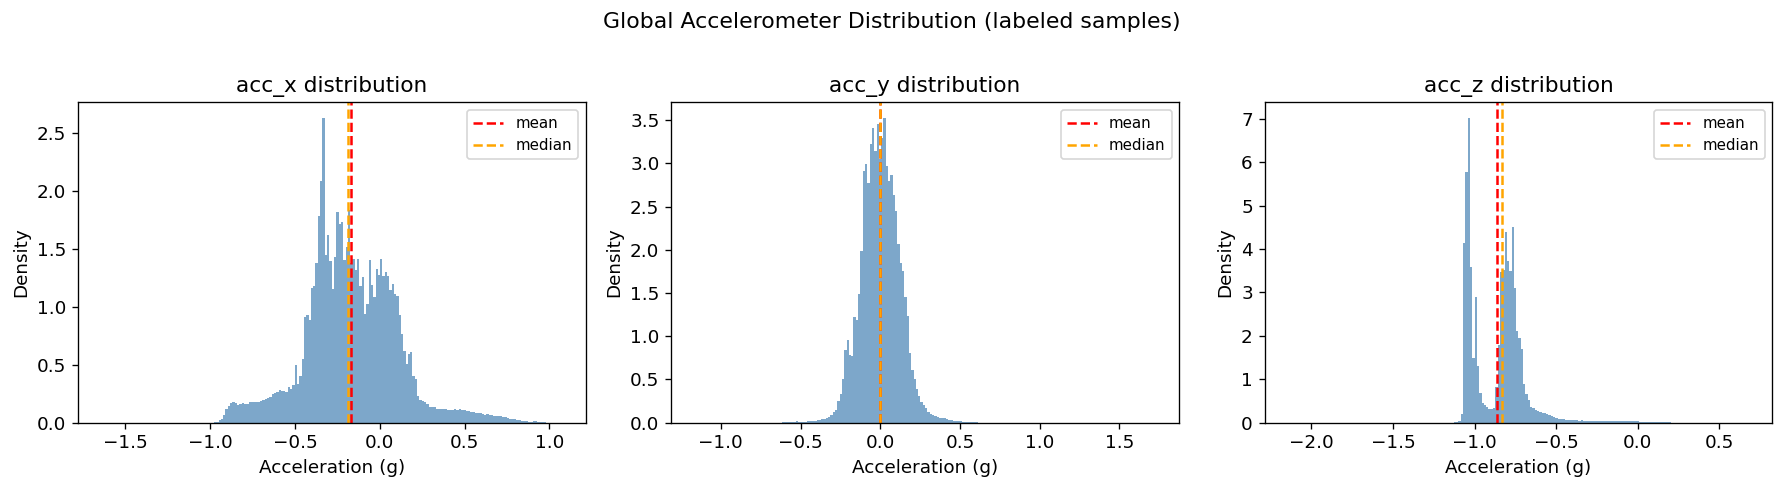

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, AXES):
    ax.hist(df_known[col].dropna(), bins=200, color='steelblue', alpha=0.7, density=True)
    ax.axvline(df_known[col].mean(), color='red', linestyle='--', label='mean')
    ax.axvline(df_known[col].median(), color='orange', linestyle='--', label='median')
    ax.set_title(f'{col} distribution')
    ax.set_xlabel('Acceleration (g)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
plt.suptitle('Global Accelerometer Distribution (labeled samples)', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'global_distribution.png'), bbox_inches='tight')
plt.show()

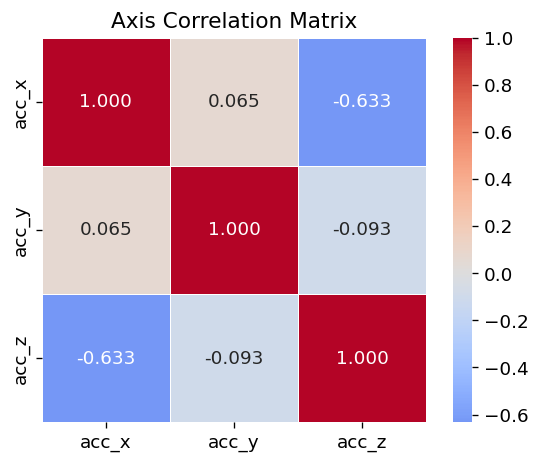

In [10]:
corr = df_known[AXES].corr()
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Axis Correlation Matrix')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'axis_correlation.png'), bbox_inches='tight')
plt.show()

## 6. Per-Class Statistics (Windowed npy)

In [11]:
rows = []
for label in labels_to_analyze:
    mask  = y == label
    x_cls = X[mask]
    for ai, axis in enumerate(AXES):
        vals = x_cls[:, ai, :].ravel()
        rows.append({'label': label, 'behavior': LABEL_NAMES.get(label, str(label)), 'axis': axis,
                     'n_windows': int(mask.sum()), 'mean': vals.mean(), 'std': vals.std(),
                     'min': vals.min(), 'max': vals.max(),
                     'p25': np.percentile(vals, 25), 'p75': np.percentile(vals, 75),
                     'skew': stats.skew(vals), 'kurtosis': stats.kurtosis(vals)})

stat_df    = pd.DataFrame(rows)
pivot_stat = stat_df.pivot_table(index=['behavior','axis'],
    values=['n_windows','mean','std','min','max','p25','p75','skew','kurtosis'])
print('=== Per-class, per-axis statistics (windowed npy, normalized) ===')
print(pivot_stat.round(3).to_string())

=== Per-class, per-axis statistics (windowed npy, normalized) ===
                       kurtosis     max   mean    min  n_windows    p25    p75   skew    std
behavior        axis                                                                        
Breathing       acc_x     0.971   3.745  0.060 -2.893      411.0 -0.597  0.705  0.305  1.038
                acc_y     0.997   5.120 -0.137 -5.310      411.0 -0.797  0.516  0.061  0.992
                acc_z     4.790   5.967 -0.050 -1.627      411.0 -1.020  0.527  1.600  1.077
Feeding         acc_x     1.103   3.561  0.446 -2.475      210.0 -0.060  0.976 -0.193  0.908
                acc_y     2.176   6.278  0.517 -3.108      210.0  0.149  0.919  0.233  0.772
                acc_z     2.978   4.284 -0.631 -2.517      210.0 -1.127  0.041  1.580  0.716
Gliding         acc_x     1.254   4.081  0.235 -2.893      501.0 -0.313  0.814 -0.039  1.010
                acc_y     0.031   3.230  0.014 -5.715      501.0 -0.726  0.831 -0.320  1.050
    

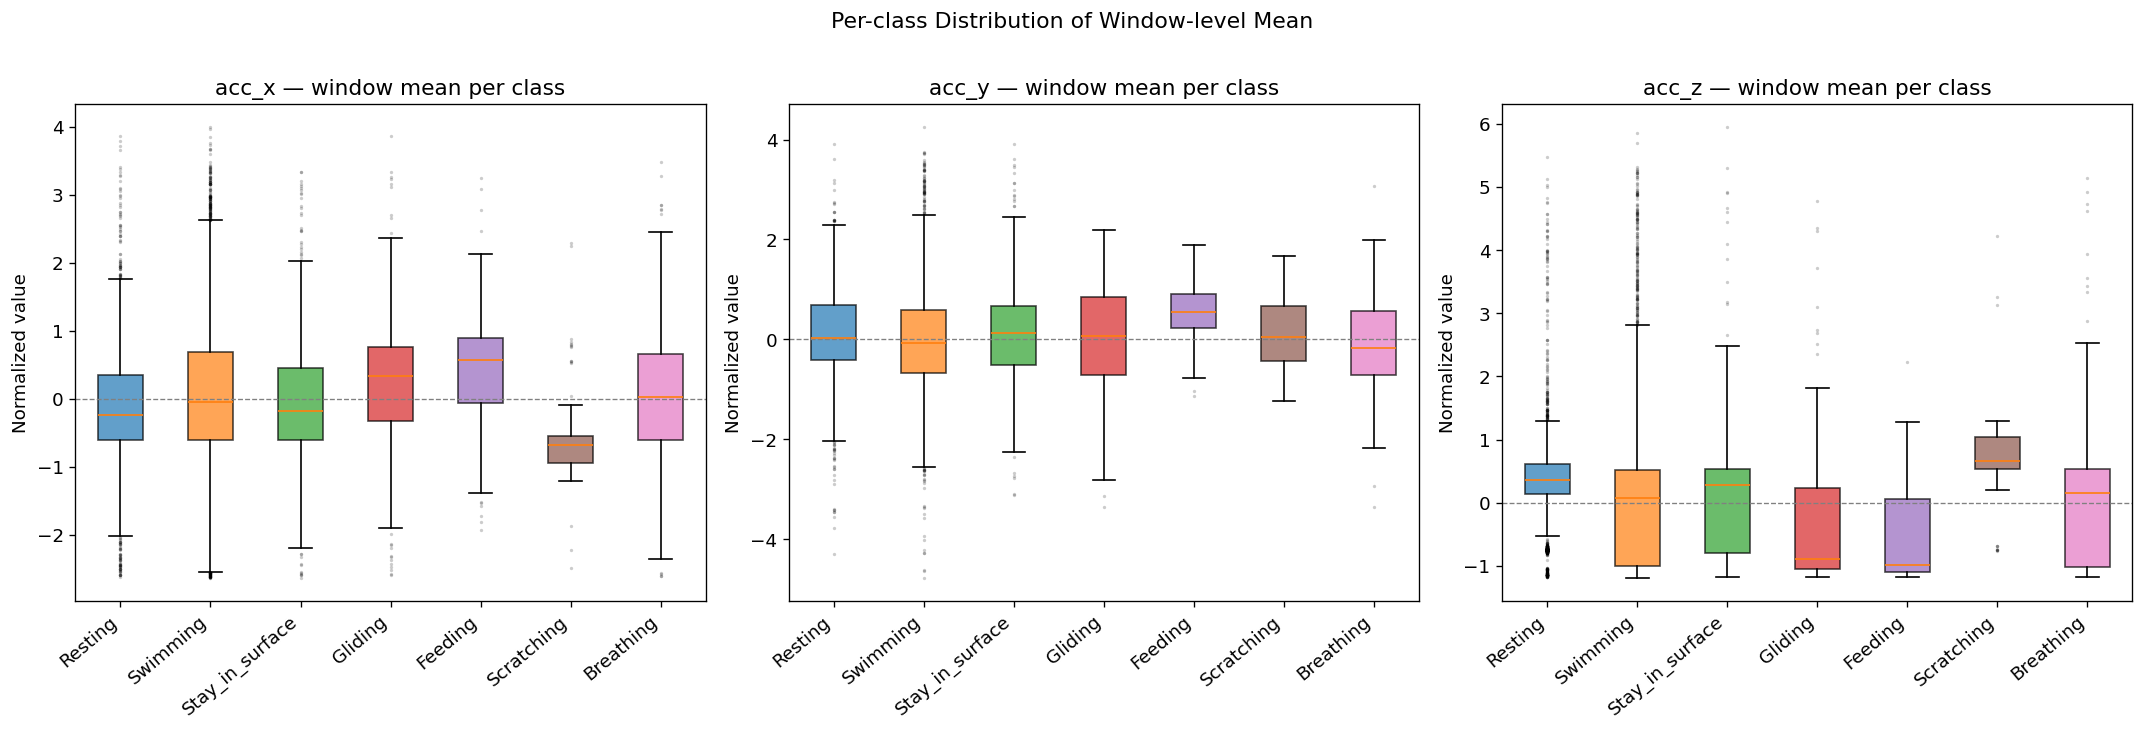

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ai, (ax, axis) in enumerate(zip(axes, AXES)):
    data_per_class = [X[y == l, ai, :].mean(axis=1) for l in labels_to_analyze]
    bp = ax.boxplot(data_per_class, labels=class_names, patch_artist=True,
                    flierprops=dict(marker='.', alpha=0.2, markersize=2))
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_title(f'{axis} — window mean per class')
    ax.set_ylabel('Normalized value')
    ax.set_xticklabels(class_names, rotation=40, ha='right')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.suptitle('Per-class Distribution of Window-level Mean', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'per_class_boxplot.png'), bbox_inches='tight')
plt.show()

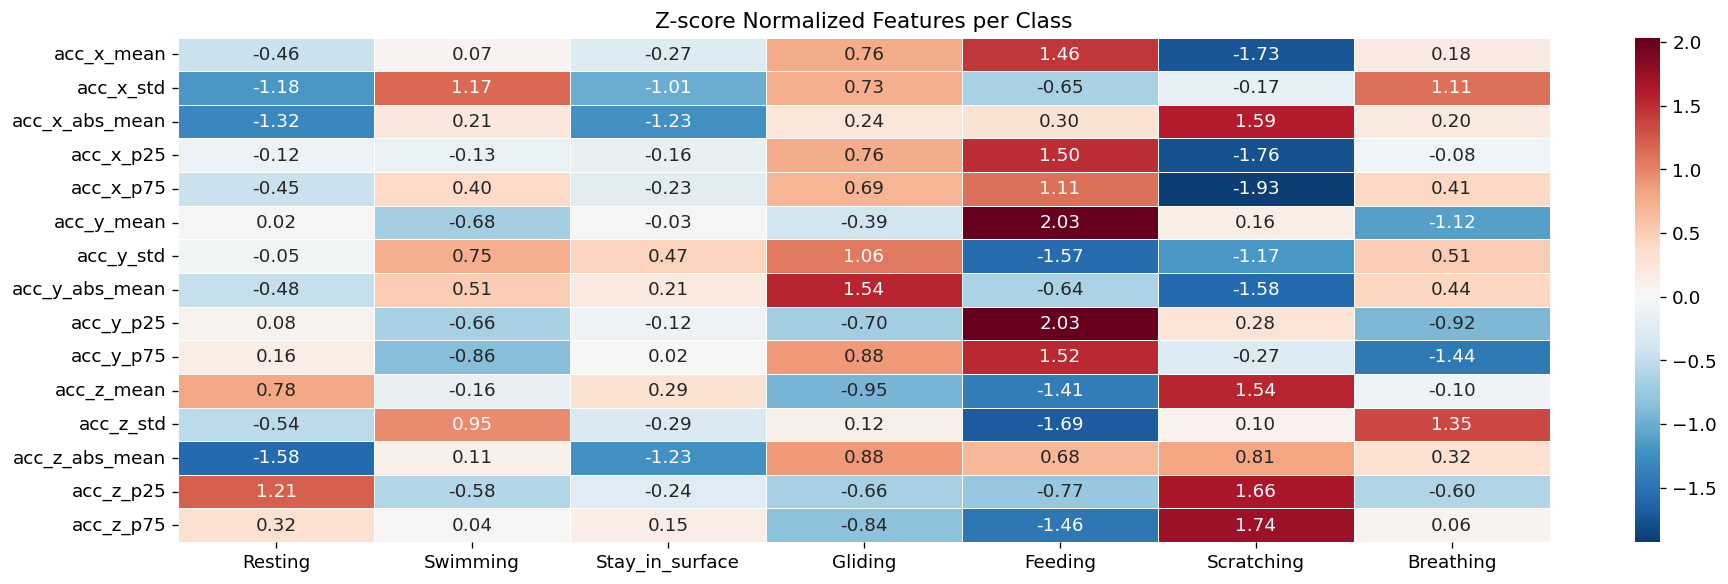

In [13]:
feat_matrix, feature_names = [], []
for label in labels_to_analyze:
    x_cls = X[y == label]
    row = []
    for ai in range(3):
        v = x_cls[:, ai, :]
        row += [v.mean(), v.std(), np.abs(v).mean(), np.percentile(v,25), np.percentile(v,75)]
    feat_matrix.append(row)
for axis in AXES:
    feature_names += [f'{axis}_mean', f'{axis}_std', f'{axis}_abs_mean', f'{axis}_p25', f'{axis}_p75']

feat_df   = pd.DataFrame(feat_matrix, index=class_names, columns=feature_names)
feat_norm = (feat_df - feat_df.mean()) / (feat_df.std() + 1e-8)
fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(feat_norm.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, linewidths=0.3)
ax.set_title('Z-score Normalized Features per Class')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'class_feature_heatmap.png'), bbox_inches='tight')
plt.show()

## 7. Signal Magnitude & Energy

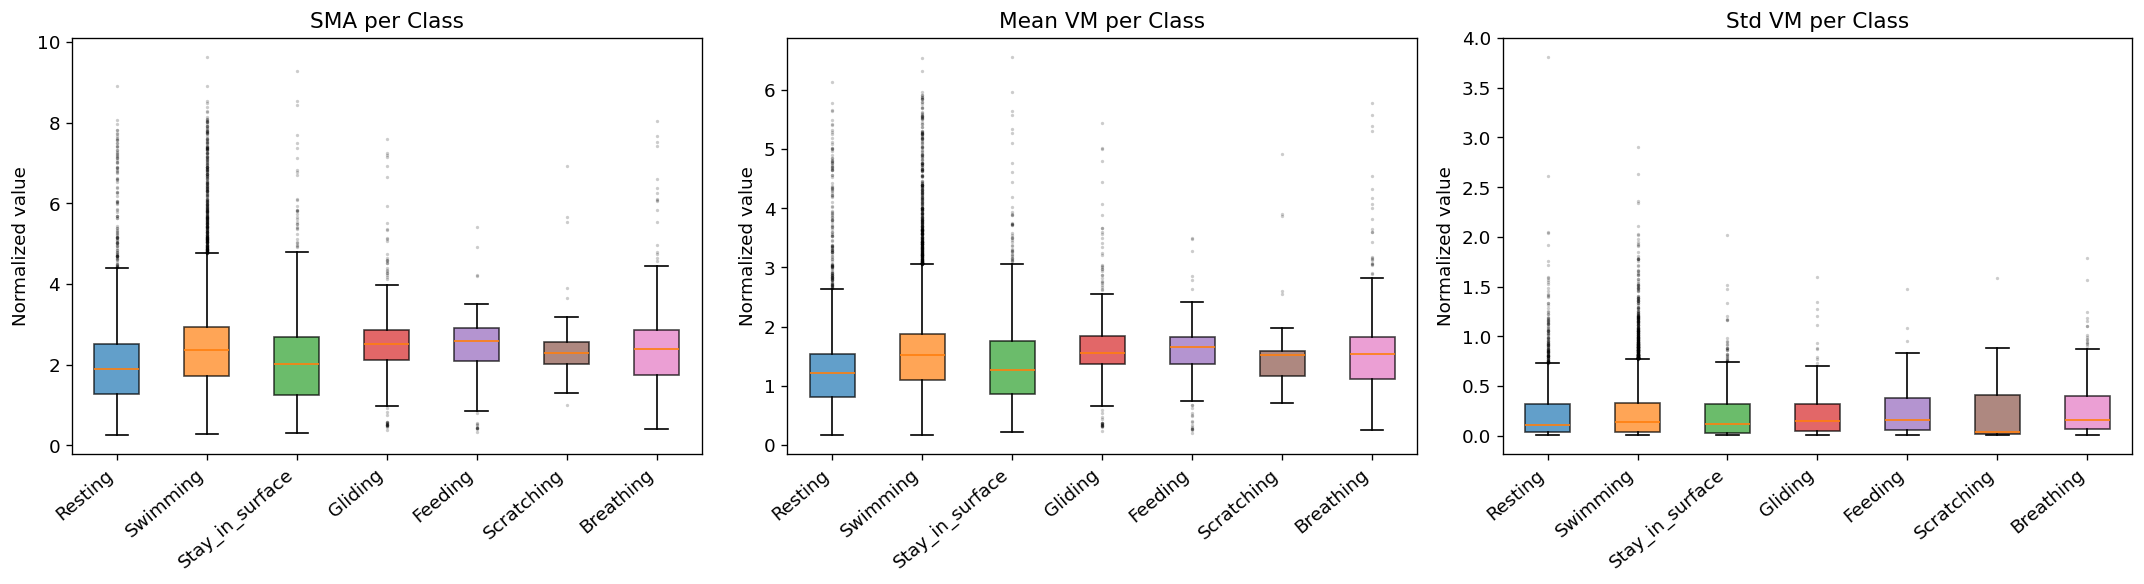

Mean SMA per class:
  0 Resting            mean=2.0487  std=1.1851
  1 Swimming           mean=2.4134  std=1.1312
  2 Stay_in_surface    mean=2.1316  std=1.1334
  3 Gliding            mean=2.5545  std=0.9481
  4 Feeding            mean=2.4115  std=0.7969
  5 Scratching         mean=2.4875  std=0.9258
  6 Breathing          mean=2.4300  std=1.1281


In [14]:
SMA     = np.abs(X).sum(axis=1).mean(axis=1)
VM_mean = np.sqrt((X**2).sum(axis=1)).mean(axis=1)
VM_std  = np.sqrt((X**2).sum(axis=1)).std(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, title in zip(axes, [SMA, VM_mean, VM_std], ['SMA', 'Mean VM', 'Std VM']):
    data_cls = [metric[y == l] for l in labels_to_analyze]
    bp = ax.boxplot(data_cls, labels=class_names, patch_artist=True,
                    flierprops=dict(marker='.', alpha=0.2, markersize=2))
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_title(f'{title} per Class')
    ax.set_xticklabels(class_names, rotation=40, ha='right')
    ax.set_ylabel('Normalized value')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'magnitude_energy.png'), bbox_inches='tight')
plt.show()

print('Mean SMA per class:')
for l, d in zip(labels_to_analyze, [SMA[y==l] for l in labels_to_analyze]):
    print(f'  {l} {LABEL_NAMES.get(l,"?"):<18} mean={d.mean():.4f}  std={d.std():.4f}')

## 8. Frequency Domain Analysis

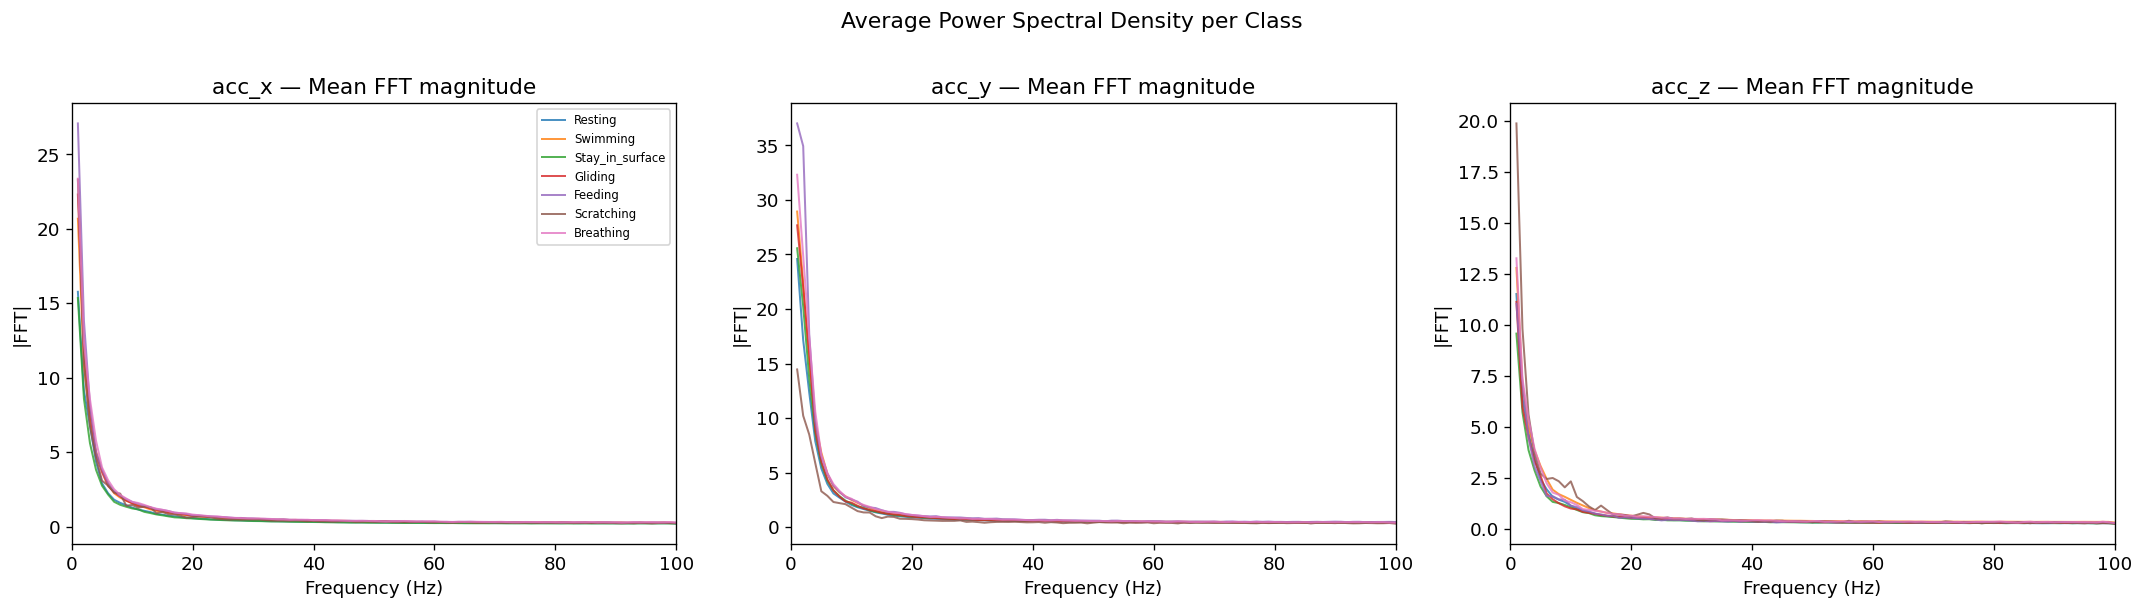

In [15]:
T     = X.shape[2]
freqs = np.fft.rfftfreq(T, d=1.0/SAMPLE_RATE)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ai, (ax, axis) in enumerate(zip(axes, AXES)):
    for li, label in enumerate(labels_to_analyze):
        x_cls   = X[y == label, ai, :]
        fft_mag = np.abs(np.fft.rfft(x_cls, axis=1)).mean(axis=0)
        ax.plot(freqs[1:], fft_mag[1:], label=LABEL_NAMES.get(label, str(label)),
                color=COLORS[li], alpha=0.8, linewidth=1.2)
    ax.set_title(f'{axis} — Mean FFT magnitude')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('|FFT|')
    ax.set_xlim(0, SAMPLE_RATE // 2)
    if ai == 0:
        ax.legend(fontsize=7, loc='upper right')
plt.suptitle('Average Power Spectral Density per Class', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'psd_per_class.png'), bbox_inches='tight')
plt.show()

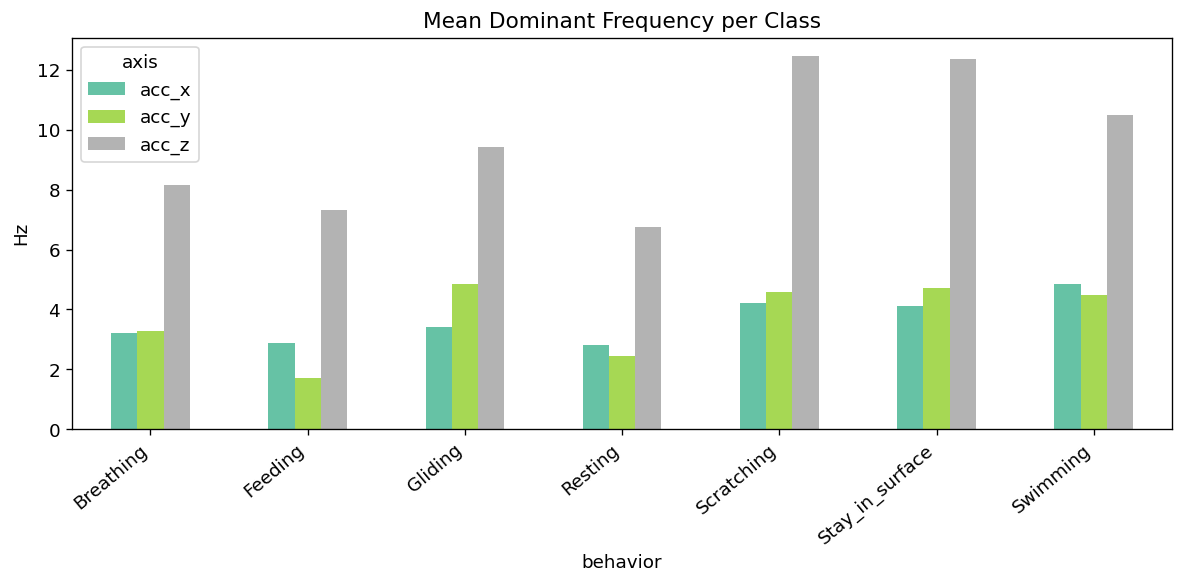

axis             acc_x  acc_y   acc_z
behavior                             
Breathing        3.224  3.290   8.144
Feeding          2.890  1.724   7.319
Gliding          3.409  4.860   9.421
Resting          2.796  2.462   6.748
Scratching       4.206  4.587  12.460
Stay_in_surface  4.117  4.732  12.379
Swimming         4.851  4.485  10.500


In [16]:
rows_dom = []
for label in labels_to_analyze:
    for ai, axis in enumerate(AXES):
        x_cls    = X[y == label, ai, :]
        fft_mag  = np.abs(np.fft.rfft(x_cls, axis=1))[:, 1:]
        dom_freq = freqs[1:][fft_mag.argmax(axis=1)]
        rows_dom.append({'behavior': LABEL_NAMES.get(label,str(label)), 'axis': axis,
                         'mean_dom_freq': dom_freq.mean(), 'std': dom_freq.std()})

pivot_dom = pd.DataFrame(rows_dom).pivot(index='behavior', columns='axis', values='mean_dom_freq')
fig, ax = plt.subplots(figsize=(10, 5))
pivot_dom.plot(kind='bar', ax=ax, colormap='Set2')
ax.set_title('Mean Dominant Frequency per Class')
ax.set_ylabel('Hz')
ax.set_xticklabels(pivot_dom.index, rotation=40, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'dominant_freq.png'), bbox_inches='tight')
plt.show()
print(pivot_dom.round(3).to_string())

## 9. Average Window Shape per Class

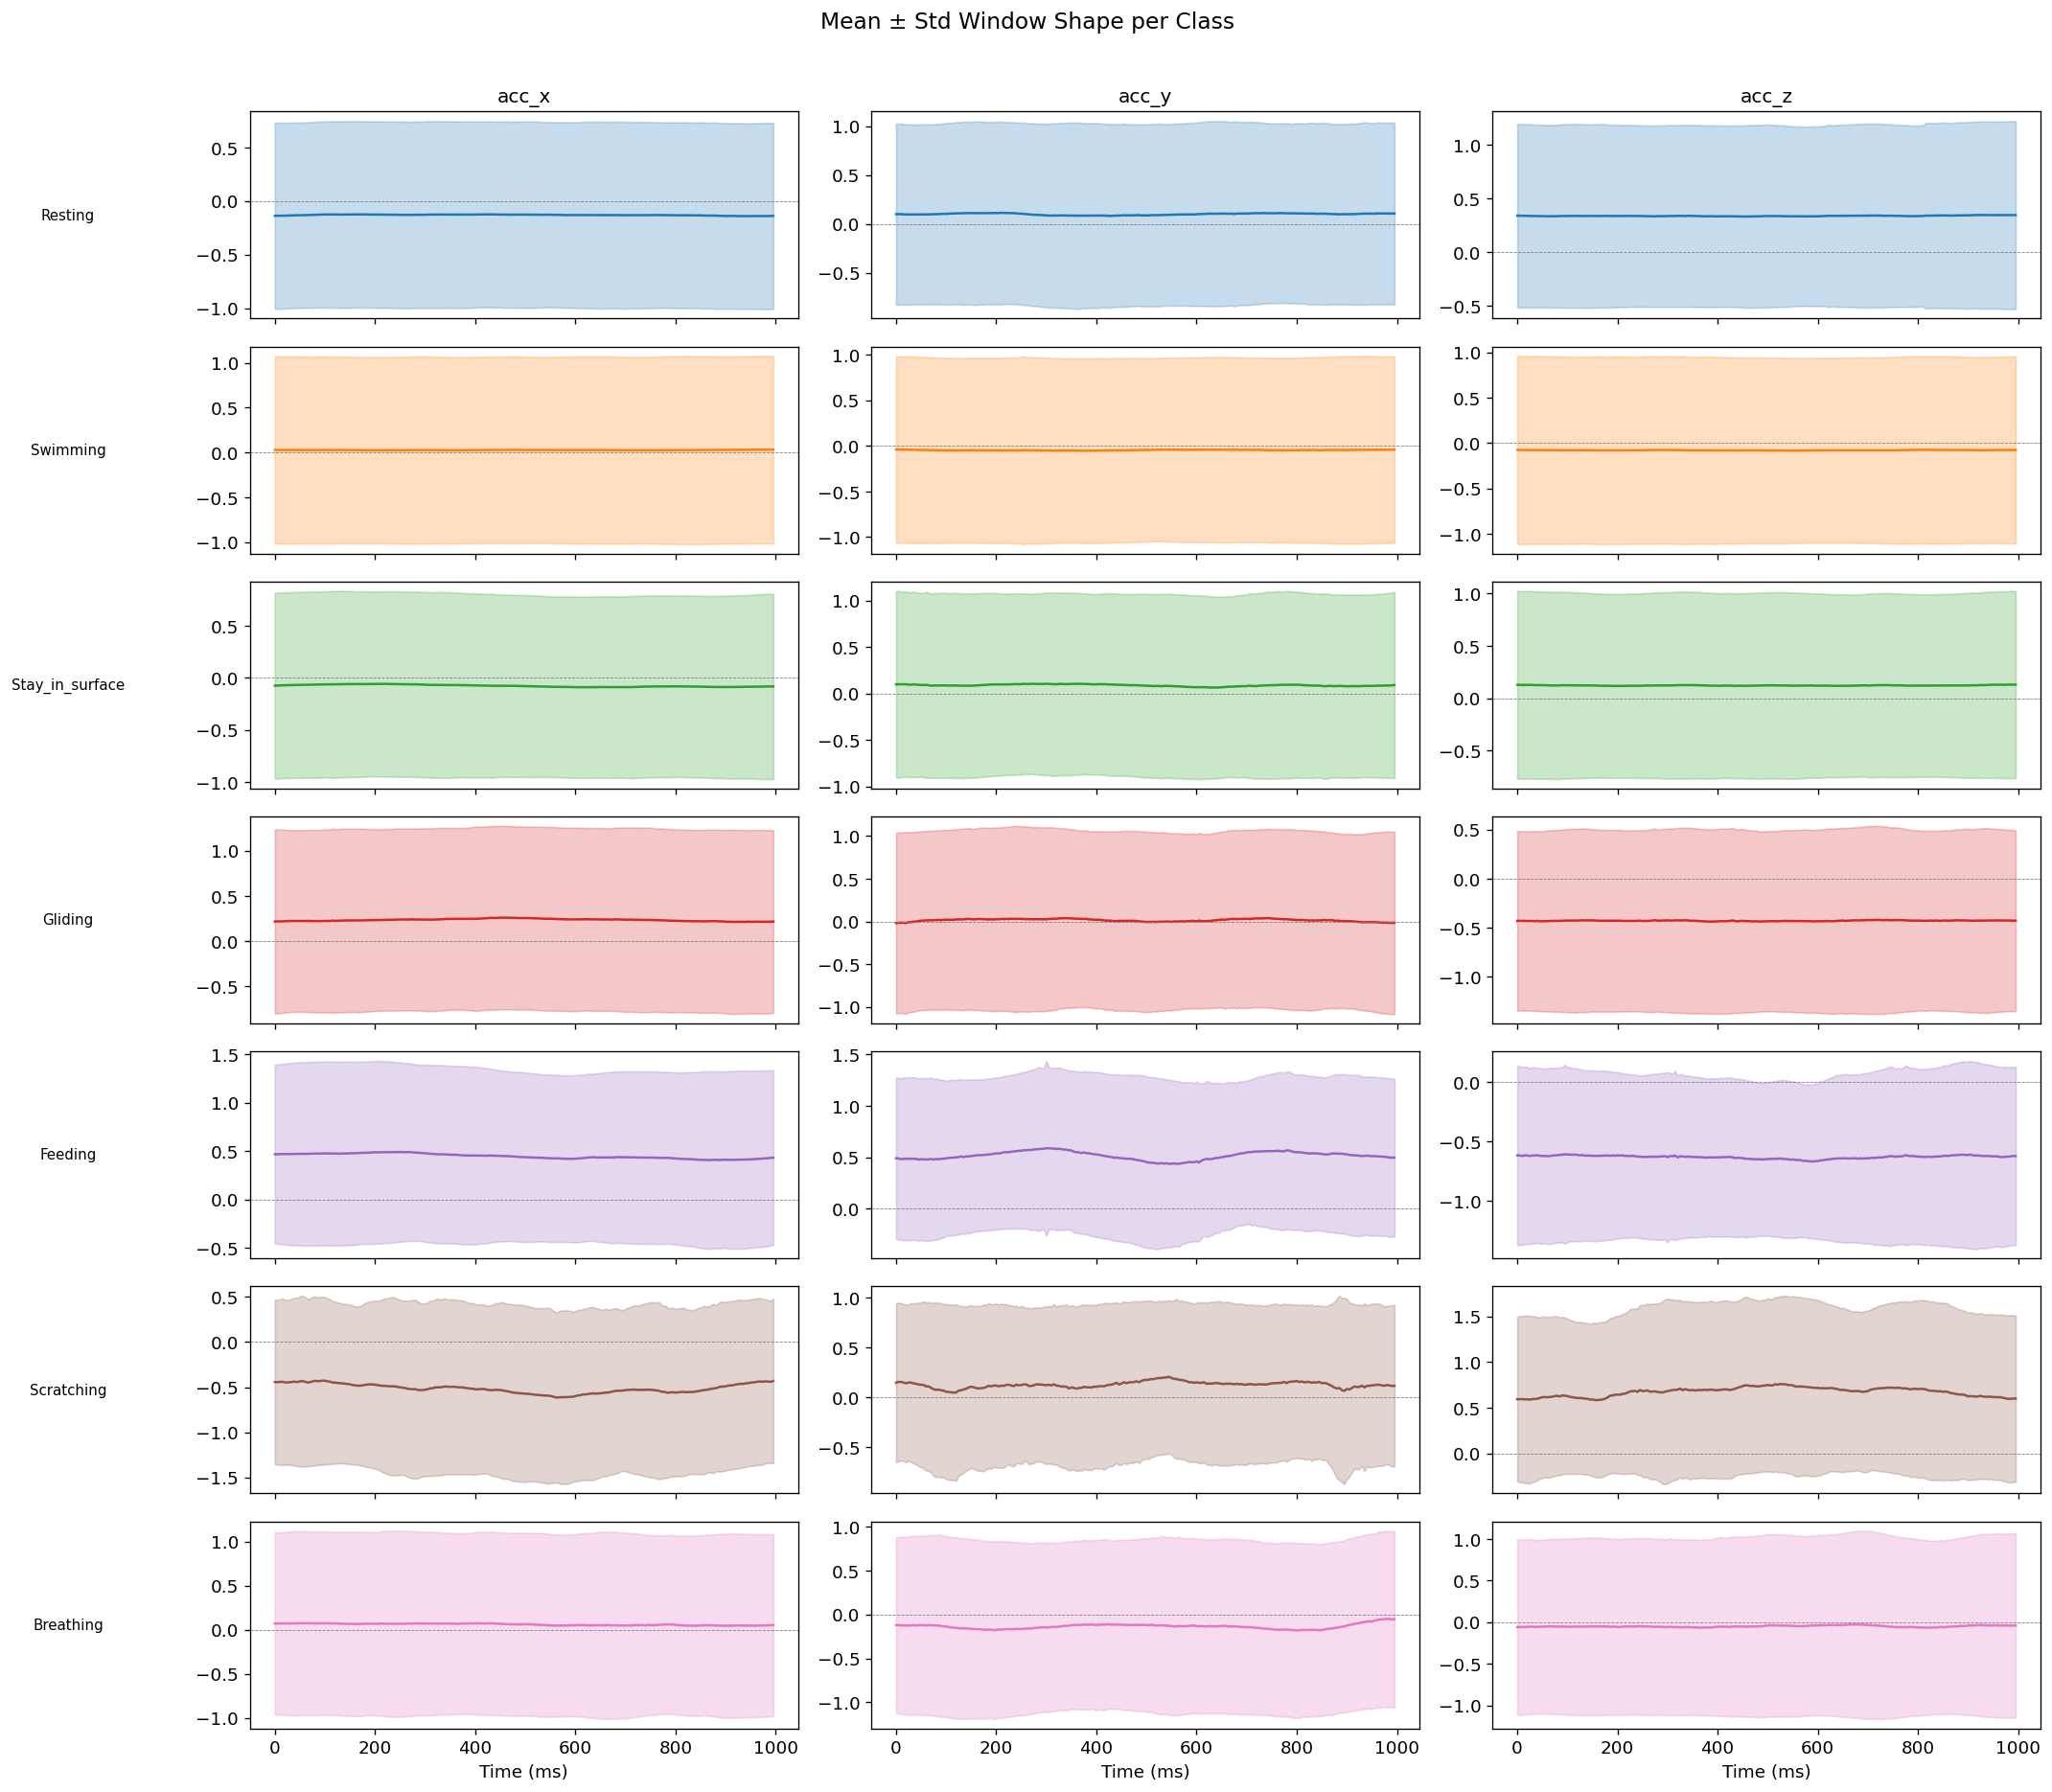

In [17]:
n_cls = len(labels_to_analyze)
fig, axes = plt.subplots(n_cls, 3, figsize=(18, 2.2 * n_cls), sharex=True)
t = np.arange(T) / SAMPLE_RATE * 1000
if n_cls == 1:
    axes = axes[np.newaxis, :]

for row, label in enumerate(labels_to_analyze):
    x_cls = X[y == label]
    for ai, axis in enumerate(AXES):
        ax = axes[row, ai]
        mu = x_cls[:, ai, :].mean(axis=0)
        sd = x_cls[:, ai, :].std(axis=0)
        ax.plot(t, mu, color=COLORS[row], linewidth=1.5)
        ax.fill_between(t, mu - sd, mu + sd, alpha=0.25, color=COLORS[row])
        ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
        if row == 0: ax.set_title(axis, fontsize=12)
        if ai == 0:
            ax.set_ylabel(LABEL_NAMES.get(label, str(label)), fontsize=9,
                          rotation=0, labelpad=80, va='center')
        if row == n_cls - 1: ax.set_xlabel('Time (ms)')

plt.suptitle('Mean ± Std Window Shape per Class', y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'avg_window_per_class.png'), bbox_inches='tight')
plt.show()

## 10. Between-Class Separability

=== Kruskal-Wallis H-test ===
  acc_x: H=42313.38, p=0.00e+00  → SIGNIFICANT
  acc_y: H=33542.81, p=0.00e+00  → SIGNIFICANT
  acc_z: H=178060.91, p=0.00e+00  → SIGNIFICANT


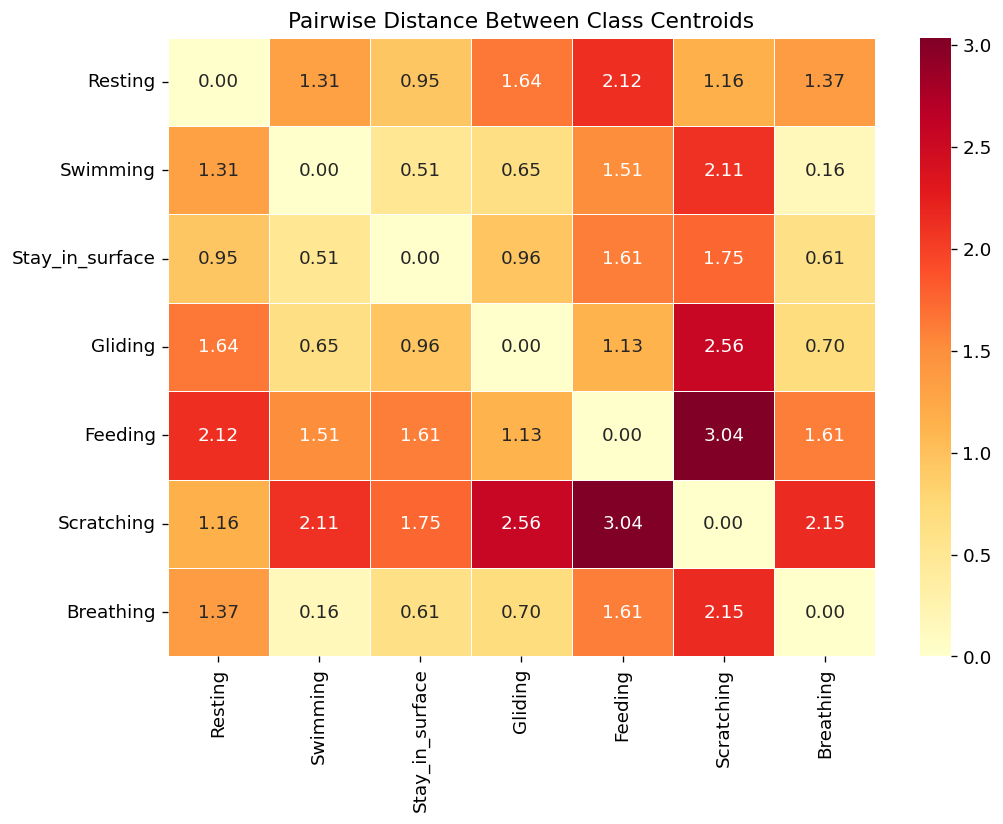

In [18]:
print('=== Kruskal-Wallis H-test ===')
for ai, axis in enumerate(AXES):
    groups = [X[y == l, ai, :].ravel() for l in labels_to_analyze if (y==l).sum() > 0]
    if len(groups) > 1:
        h, pv = kruskal(*groups)
        print(f'  {axis}: H={h:.2f}, p={pv:.2e}  → {"SIGNIFICANT" if pv < 0.05 else "not significant"}')

def class_centroid(x_cls):
    feats = []
    for ai in range(3):
        v = x_cls[:, ai, :]
        feats += [v.mean(axis=1).mean(), v.std(axis=1).mean(),
                  np.percentile(v,25), np.percentile(v,75), np.abs(v).mean()]
    return np.array(feats)

centroids = np.array([class_centroid(X[y == l]) for l in labels_to_analyze])
dist_mat  = pairwise_distances(centroids)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(dist_mat, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=class_names, yticklabels=class_names, ax=ax, linewidths=0.3)
ax.set_title('Pairwise Distance Between Class Centroids')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'pairwise_class_distance.png'), bbox_inches='tight')
plt.show()

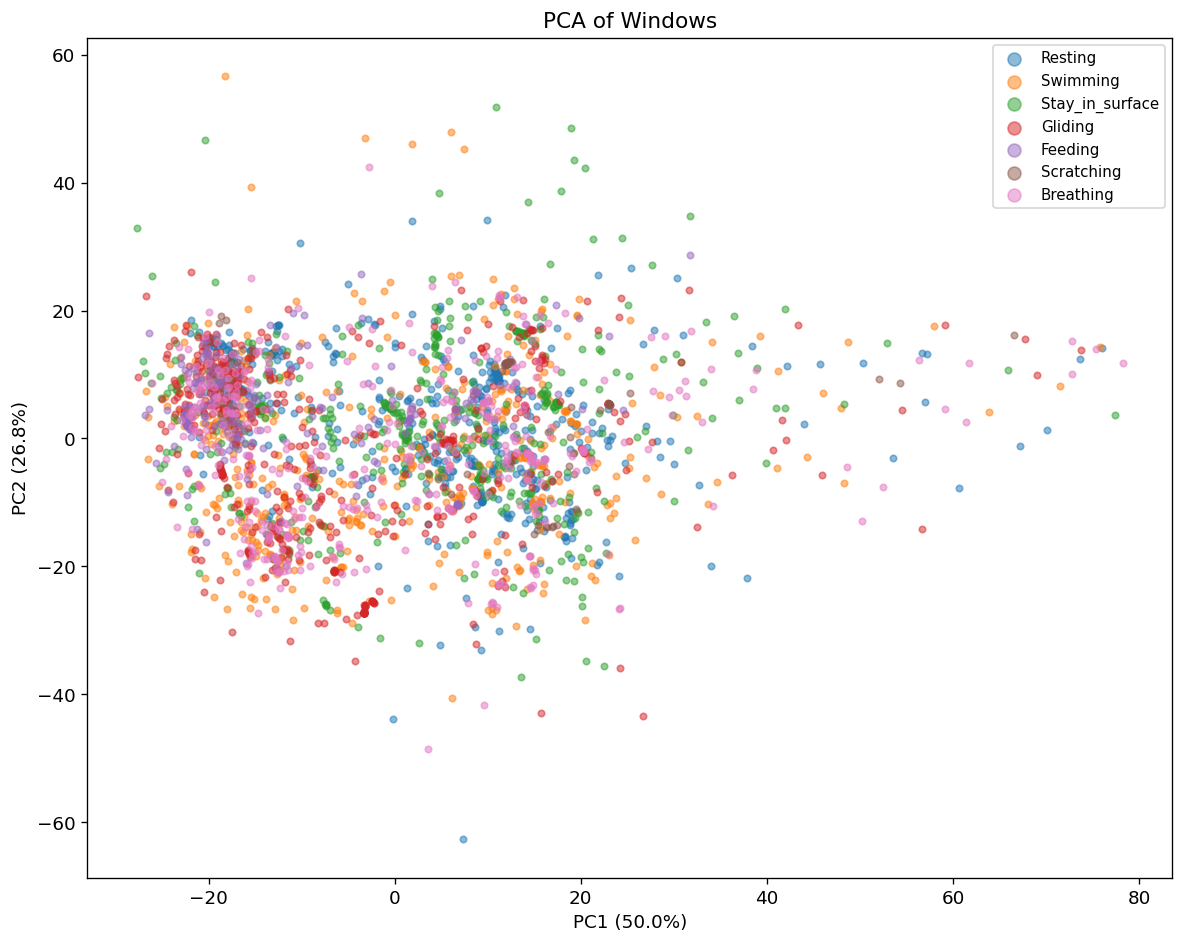

Variance explained PC1+PC2: 76.8%


In [19]:
N_PER_CLASS = 500
idx_all = []
for label in labels_to_analyze:
    idx_l = np.where(y == label)[0]
    n_take = min(N_PER_CLASS, len(idx_l))
    idx_all.append(np.random.choice(idx_l, n_take, replace=False))
idx_all = np.concatenate(idx_all)
X_flat  = X[idx_all].reshape(len(idx_all), -1)
y_sub   = y[idx_all]

pca   = PCA(n_components=2)
X_pca = pca.fit_transform(X_flat)
fig, ax = plt.subplots(figsize=(10, 8))
for li, label in enumerate(labels_to_analyze):
    mask = y_sub == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[COLORS[li]],
               label=LABEL_NAMES.get(label, str(label)), alpha=0.5, s=15)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA of Windows')
ax.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'pca_visualization.png'), bbox_inches='tight')
plt.show()
print(f'Variance explained PC1+PC2: {pca.explained_variance_ratio_[:2].sum()*100:.1f}%')

## 11. Axis Cross-Correlation per Class

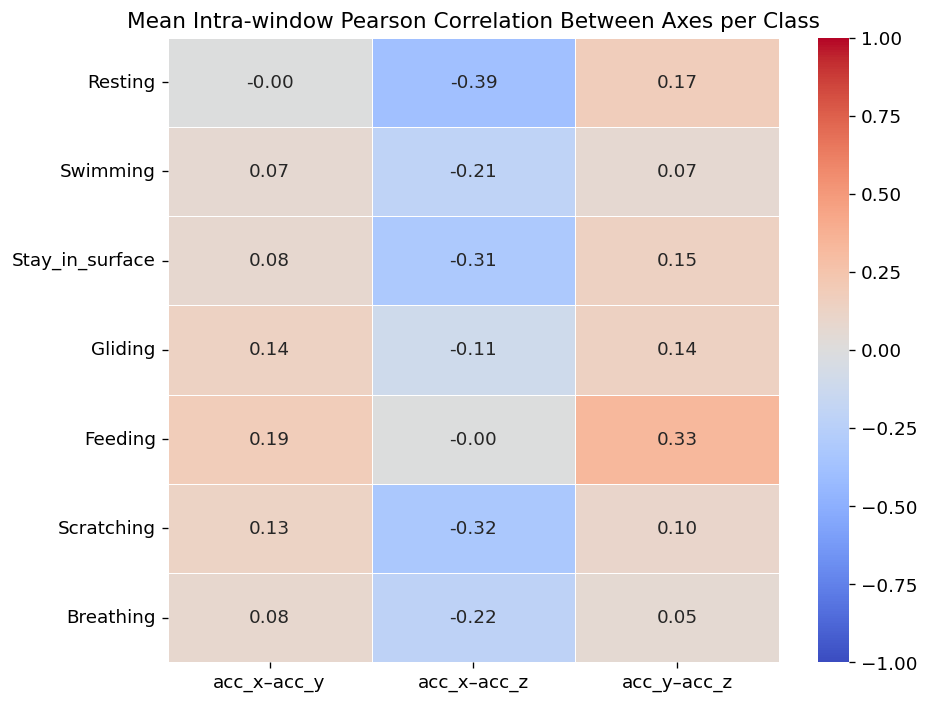

In [20]:
axis_pairs = [('acc_x','acc_y',0,1), ('acc_x','acc_z',0,2), ('acc_y','acc_z',1,2)]
corr_data  = {f'{a}–{b}': [] for a,b,_,__ in axis_pairs}
for label in labels_to_analyze:
    x_cls = X[y == label]
    for a_name, b_name, ai, bi in axis_pairs:
        r_vals = [np.corrcoef(x_cls[n, ai], x_cls[n, bi])[0, 1] for n in range(len(x_cls))]
        corr_data[f'{a_name}–{b_name}'].append(np.nanmean(r_vals))

corr_df = pd.DataFrame(corr_data, index=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Mean Intra-window Pearson Correlation Between Axes per Class')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'axis_xcorr_per_class.png'), bbox_inches='tight')
plt.show()

## 12. Window Quality & Label Consistency

In [21]:
y_all    = Y.astype(int)
all_same = np.array([(row[row >= 0] == row[row >= 0][0]).all() if (row >= 0).sum() > 0 else False
                     for row in y_all])
print(f'Windows with 100% consistent labels : {all_same.sum():,} / {len(all_same):,} ({all_same.mean()*100:.1f}%)')
print(f'Mixed-label windows                 : {(~all_same).sum():,} ({(~all_same).mean()*100:.1f}%)')
print(f'Window: {T} timesteps = {T/SAMPLE_RATE*1000:.0f} ms at {SAMPLE_RATE} Hz')
print(f'Total windows: {len(X):,}')
for ai, axis in enumerate(AXES):
    v = X[:, ai, :]
    print(f'{axis}: min={v.min():.4f}  max={v.max():.4f}  mean={v.mean():.6f}  std={v.std():.6f}')

Windows with 100% consistent labels : 15,121 / 15,619 (96.8%)
Mixed-label windows                 : 498 (3.2%)
Window: 200 timesteps = 1000 ms at 200 Hz
Total windows: 15,619
acc_x: min=-5.3009  max=4.4729  mean=0.000219  std=1.000408
acc_y: min=-9.5865  max=14.1921  mean=0.000422  std=1.000120
acc_z: min=-7.4226  max=10.7039  mean=0.000341  std=1.001133


## 13. Depth (Pressure) Analysis

=== Pressure statistics (raw, labeled samples) ===
count    3.124374e+06
mean    -8.636600e+00
std      5.260500e+00
min     -2.906100e+01
25%     -1.163510e+01
50%     -8.505600e+00
75%     -5.474900e+00
max      0.000000e+00


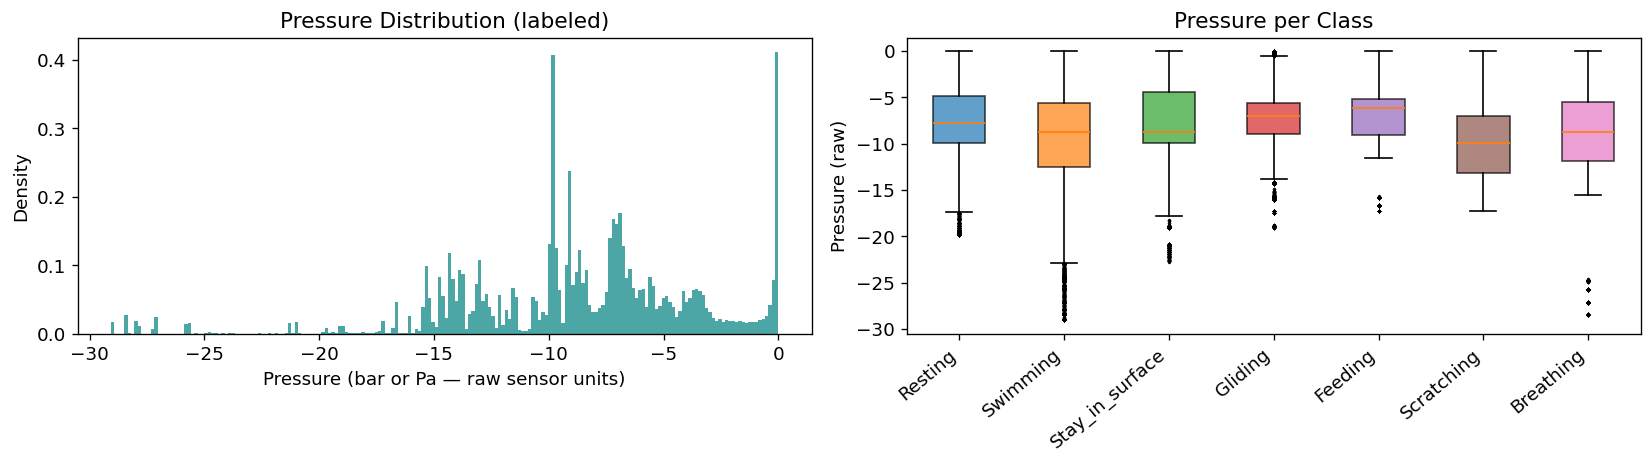

In [22]:
# Pressure is the 7th channel (index 6) of the raw h5 data
# It is NOT normalized in the windowed data.npy (only acc channels are).
# Use raw labeled df for pressure statistics.
if 'pressure' in df_known.columns:
    print('=== Pressure statistics (raw, labeled samples) ===')
    print(df_known['pressure'].describe().round(4).to_string())

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    ax = axes[0]
    ax.hist(df_known['pressure'].dropna(), bins=200, color='teal', alpha=0.7, density=True)
    ax.set_title('Pressure Distribution (labeled)')
    ax.set_xlabel('Pressure (bar or Pa — raw sensor units)')
    ax.set_ylabel('Density')

    ax = axes[1]
    pres_cls = [df_known[df_known['label_id'] == l]['pressure'].dropna().values
                for l in labels_to_analyze]
    bp = ax.boxplot(pres_cls, labels=class_names, patch_artist=True,
                    flierprops=dict(marker='.', alpha=0.1, markersize=2))
    for patch, color in zip(bp['boxes'], COLORS[:len(labels_to_analyze)]):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_title('Pressure per Class')
    ax.set_xticklabels(class_names, rotation=40, ha='right')
    ax.set_ylabel('Pressure (raw)')
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'pressure_analysis.png'), bbox_inches='tight')
    plt.show()

## 14. Summary Table

In [23]:
summary_rows = []
for label, pi in zip(labels_to_analyze, p):
    mask    = y == label
    x_cls   = X[mask]
    sma_val = np.abs(x_cls).sum(axis=1).mean(axis=1).mean()
    vm_val  = np.sqrt((x_cls**2).sum(axis=1)).mean(axis=1).mean()
    row = {'label': label, 'behavior': LABEL_NAMES.get(label, str(label)),
           'n_windows': int(mask.sum()), 'prop_%': round(pi * 100, 2),
           'inv_freq_weight': round((1/pi) / sum(1/q for q in p if q > 0), 4) if pi > 0 else 0,
           'SMA_mean': round(float(sma_val), 4), 'VM_mean': round(float(vm_val), 4)}
    for ai, axis in enumerate(AXES):
        v = x_cls[:, ai, :]
        row[f'{axis}_mean'] = round(float(v.mean()), 4)
        row[f'{axis}_std']  = round(float(v.std()),  4)
        row[f'{axis}_min']  = round(float(v.min()),  4)
        row[f'{axis}_max']  = round(float(v.max()),  4)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('label')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)
print('=== Summary Table ===')
print(summary_df.to_string())

=== Summary Table ===
              behavior  n_windows  prop_%  inv_freq_weight  SMA_mean  VM_mean  acc_x_mean  acc_x_std  acc_x_min  acc_x_max  acc_y_mean  acc_y_std  acc_y_min  acc_y_max  acc_z_mean  acc_z_std  acc_z_min  acc_z_max
label                                                                                                                                                                                                               
0              Resting       2819   18.05           0.0135    2.0487   1.3187     -0.1310     0.8686    -2.9621     4.1376      0.1003     0.9328    -6.1054     7.1407      0.3403     0.8530    -1.5822    10.7039
1             Swimming      10217   65.41           0.0037    2.4134   1.5738      0.0269     1.0416    -5.3009     4.4729     -0.0458     1.0166    -9.5865    14.1921     -0.0782     1.0294    -7.4226     8.9059
2      Stay_in_surface       1398    8.95           0.0273    2.1316   1.3761     -0.0757     0.8811    -3.2303     3.6034    